In [3]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from geopy.distance import geodesic
from shapely.geometry import LineString
import contextily as ctx

In [4]:
building_df = pd.read_csv('building_results_unmitigated.csv')
building_df_mitigated = pd.read_csv('building_results_mitigated.csv')


In [5]:
building_df

,uid,Building_n,Latitude,Longitude,Base_eleva,Barrier_ht,Floors,Height,Occupancy,From_Node,...,DS_powerfail,nearest_node,time,recov,mean_downtime,std_downtime,time_power,recov_power,mean_downtime_power,std_downtime_power
0,1,House1,38.980200,-76.485999,0,0,2,30,RES3,6,...,0.784903,640,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. ...,0.000000e+00,0.000000,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0
1,2,House2,38.979932,-76.485676,0,0,2,30,RES3,6,...,0.784903,341,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[1. 1. 1. 1. 1...,1.184000e-07,0.001650,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0
2,3,House3,38.979717,-76.485350,0,0,2,30,RES3,6,...,0.784903,28,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[1. 1. 1. 1. 1...,3.767200e-06,0.009308,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0
3,4,House4,38.979495,-76.485058,0,0,2,30,RES3,6,...,0.784903,523,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[1. 1. 1. 1. 0...,2.348930e-04,0.073501,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0
4,5,House5,38.979286,-76.484716,0,0,2,30,RES3,6,...,0.784903,410,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. ...,0.000000e+00,0.000000,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0
5,6,House6,38.979127,-76.484436,0,0,2,30,RES3,6,...,0.784903,642,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[1.76003086e-07 9.39799589e-07 4.50883716e-06 ...,3.237015e+01,22.342562,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0
6,7,House7,38.979546,-76.484895,0,0,2,30,RES3,6,...,0.784903,596,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. ...,0.000000e+00,0.000000,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0
7,8,Main Hall,38.981453,-76.482890,0,0,3,40,EDU2,6,...,0.784903,254,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[2.86603784e-07 1.53037157e-06 7.34219965e-06 ...,1.500749e+01,3.029039,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0
8,9,US Naval Academy Museum,38.982788,-76.487257,0,0,3,40,EDU2,6,...,0.784903,235,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[2.86586413e-07 1.53027881e-06 7.34175463e-06 ...,1.501022e+01,3.049501,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0
9,10,Mahan Hall/Sampson Hall/Maury Hall,38.983863,-76.486731,0,0,3,40,EDU2,6,...,0.784903,564,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[2.06567954e-07 1.10300610e-06 5.29184621e-06 ...,2.757193e+01,20.592714,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0


In [6]:
building_df_mitigated

,uid,Building_n,Latitude,Longitude,Base_eleva,Barrier_ht,Floors,Height,Occupancy,From_Node,...,DS_powerfail,nearest_node,time,recov,mean_downtime,std_downtime,time_power,recov_power,mean_downtime_power,std_downtime_power
0,1,House1,38.980200,-76.485999,0,2.5,2,30,RES3,6,...,0.784903,640,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. ...,0.000000,0.000000,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0
1,2,House2,38.979932,-76.485676,0,2.5,2,30,RES3,6,...,0.784903,341,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. ...,0.000000,0.000000,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0
2,3,House3,38.979717,-76.485350,0,2.5,2,30,RES3,6,...,0.784903,28,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. ...,0.000000,0.000000,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0
3,4,House4,38.979495,-76.485058,0,2.5,2,30,RES3,6,...,0.784903,523,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. ...,0.000000,0.000000,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0
4,5,House5,38.979286,-76.484716,0,2.5,2,30,RES3,6,...,0.784903,410,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. ...,0.000000,0.000000,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0
5,6,House6,38.979127,-76.484436,0,2.5,2,30,RES3,6,...,0.784903,642,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[1.76003086e-07 9.39799589e-07 4.50883716e-06 ...,32.370154,22.342562,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0
6,7,House7,38.979546,-76.484895,0,2.5,2,30,RES3,6,...,0.784903,596,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. ...,0.000000,0.000000,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0
7,8,Main Hall,38.981453,-76.482890,0,8.0,3,40,EDU2,6,...,0.784903,254,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. ...,0.000000,0.000000,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0
8,9,US Naval Academy Museum,38.982788,-76.487257,0,8.0,3,40,EDU2,6,...,0.784903,235,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. ...,0.000000,0.000000,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0
9,10,Mahan Hall/Sampson Hall/Maury Hall,38.983863,-76.486731,0,8.0,3,40,EDU2,6,...,0.784903,564,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. ...,[2.06567954e-07 1.10300610e-06 5.29184621e-06 ...,27.571928,20.592714,[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.],[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.],0,0


In [11]:
# building_df
def parse_space_list(s):
    # Remove brackets and split by space
    s = s.strip('[]')            # remove square brackets
    return [float(x) for x in s.split() if x.strip() != '']

# Apply this to your column
# df['values'] = df['values'].apply(parse_space_list)

In [13]:
# Assume the column with the list is named 'values'
building_df['time'] = building_df['time'].apply(parse_space_list)
building_df_mitigated['time'] = building_df_mitigated['time'].apply(parse_space_list)
building_df['recov'] = building_df['recov'].apply(parse_space_list)
building_df_mitigated['recov'] = building_df_mitigated['recov'].apply(parse_space_list)

/var/folders/_b/r78mpzpn3k7b9gn2yhys_nr80000gn/T/ipykernel_77668/1947826503.py:12: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,np.max(time))


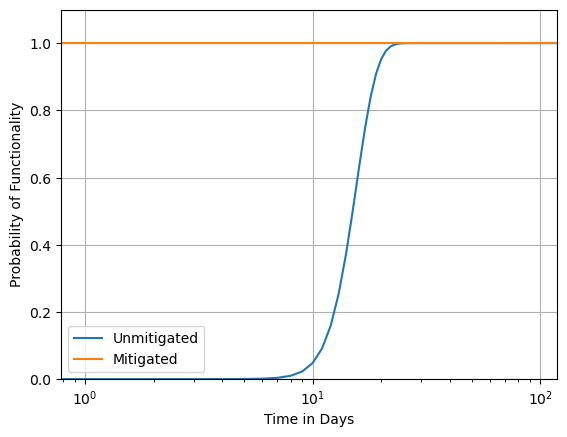

In [23]:
building_id = 11

time = building_df.loc[building_id, 'time']
functionality1 = building_df.loc[building_id, 'recov']
functionality2 = building_df_mitigated.loc[building_id, 'recov']

plt.xscale('log')
plt.plot(time, functionality1, label = 'Unmitigated')
plt.plot(time, functionality2, label = 'Mitigated')
plt.grid(True)
plt.ylim(0,1.1)
plt.xlim(0,np.max(time))
plt.xlabel('Time in Days')
plt.ylabel('Probability of Functionality')
plt.legend()

plt.show()

In [4]:
building_df['mean_downtime'].sum()

159.86553885091286

In [5]:
building_df_mitigated['mean_downtime'].sum()

114.84644454857104

In [26]:
building_df_mitigated.LS_2.sum()

1.2188098665

In [28]:
building_df.LS_2.sum()

1.2192290593